# Selenium이란?
* 웹브라우저를 자동으로 제어하는 라이브러리
* 원래 다양한 웹브라우저를 자동으로 테스트하는 도구
* 코드를 통해 웹브라우저 조작 가능
* 동적 웹사이트에서 정보를 가져오는데 활용

In [6]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by  import By
from selenium.webdriver.common.keys import Keys

options = Options()
options.add_experimental_option("detach", True)
options.add_argument("start-maximized")
options.add_argument("Chrome/135.0.0.0")
options.add_argument("lang=ko_KR")

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
    )
driver.get("https://search.shopping.naver.com/book/search?bookTabType=ALL&pageIndex=1&pageSize=40&prevQuery=%EB%84%A4%EC%9D%B4%EB%B2%84%20%EC%B1%85&query=%ED%8C%8C%EC%9D%B4%EC%8D%AC&sort=REL")

# selenium에서 원하는 요소찾기
* driver.find_element(By.CSS_SELECTOR, css셀렉터): 1개의 요소 찾기
* driver.find_element(By.CSS_SELECTOR, css셀렉터): 여러개의 요소 찾기, list반환
* driver.find_element(By.ID, "id"):html에서 id 속성을 찾아줌
* driver.find_element(By.LINK_TEXT, "link에 포함된 문자"): link에 포함된 문자 찾기
* driver.find_element(By.PARTIAL_LINK_TEXT, "link에 포함된 일부 문자"): link에 포함된 문자 찾기

In [4]:
driver

<selenium.webdriver.chrome.webdriver.WebDriver (session="f649dd7dbfe8b524372ccceece6cb289")>

In [7]:
for el in driver.find_elements(By.CSS_SELECTOR, "div.bookListItem_title__1mWGq"):
    print(el)
#    print(el.text)
#     print(el.get_attribute('outerHTML'))

<selenium.webdriver.remote.webelement.WebElement (session="99445aec871f88532be896a90f128b05", element="f.4FBED71EECAE607CFF9D5380F9433DE2.d.43BAE296C9ACB1A32C13EC283CA9F537.e.128")>
<selenium.webdriver.remote.webelement.WebElement (session="99445aec871f88532be896a90f128b05", element="f.4FBED71EECAE607CFF9D5380F9433DE2.d.43BAE296C9ACB1A32C13EC283CA9F537.e.129")>
<selenium.webdriver.remote.webelement.WebElement (session="99445aec871f88532be896a90f128b05", element="f.4FBED71EECAE607CFF9D5380F9433DE2.d.43BAE296C9ACB1A32C13EC283CA9F537.e.130")>
<selenium.webdriver.remote.webelement.WebElement (session="99445aec871f88532be896a90f128b05", element="f.4FBED71EECAE607CFF9D5380F9433DE2.d.43BAE296C9ACB1A32C13EC283CA9F537.e.131")>
<selenium.webdriver.remote.webelement.WebElement (session="99445aec871f88532be896a90f128b05", element="f.4FBED71EECAE607CFF9D5380F9433DE2.d.43BAE296C9ACB1A32C13EC283CA9F537.e.132")>
<selenium.webdriver.remote.webelement.WebElement (session="99445aec871f88532be896a90f128b0

In [28]:
driver.find_element(By.ID, "book_list").get_attribute("innerHTML")

InvalidSessionIdException: Message: invalid session id
Stacktrace:
	GetHandleVerifier [0x00E980E3+60707]
	GetHandleVerifier [0x00E98124+60772]
	(No symbol) [0x00CC04FE]
	(No symbol) [0x00CFB898]
	(No symbol) [0x00D2CF06]
	(No symbol) [0x00D289D5]
	(No symbol) [0x00D27F66]
	(No symbol) [0x00C936E5]
	(No symbol) [0x00C93C3E]
	(No symbol) [0x00C940CD]
	GetHandleVerifier [0x010DBBC3+2435075]
	GetHandleVerifier [0x010D7163+2416035]
	GetHandleVerifier [0x010F350C+2531660]
	GetHandleVerifier [0x00EAF1B5+155125]
	GetHandleVerifier [0x00EB5B5D+182173]
	(No symbol) [0x00C933B0]
	(No symbol) [0x00C92BC3]
	GetHandleVerifier [0x011FD2AC+3620588]
	BaseThreadInitThunk [0x75CFFCC9+25]
	RtlGetAppContainerNamedObjectPath [0x773182AE+286]
	RtlGetAppContainerNamedObjectPath [0x7731827E+238]


In [ ]:
driver.find_elements(By.CSS_SELECTOR, ".")

In [24]:
driver.find_element(By.CSS_SELECTOR, ".bookListItem_item_inner__edK7P").text

'컴퓨터/IT 103위\n혼자 만들면서 공부하는 파이썬 (37개 라이브러리와 API로 보고서, 차트, 게임, 맵, AI 챗봇 만들기|저자 직강 유튜브 강의, 오픈 채팅 제공)\n저자\n문현일\n출판\n한빛미디어\n2025.02.14.\n평점5.0 (4)\n도서\n판매처 134\n최저 23,400원\ne북\n판매처 4\n구매 18,720원\n신고'

In [9]:
driver.find_element(By.CSS_SELECTOR, ".bookListItem_grade__e60mi").text

'평점5.0 (4)'

# 찾은 요소에서 요소의 속성값 출력하기
* find_element(By.CSS_SELECTOR, "css셀렉터").get_attribute("속성명")

In [54]:
seller_link  = "#book_list > ul > li:nth-child(1) > div > div > div:nth-child(1) > a"

In [57]:
driver.find_element(By.CSS_SELECTOR, seller_link).get_attribute("data-shp-page-key")

'100388780'

In [39]:
import time
y = 0
y_step = 1000
for scroll_times in range(1, 8):
    y = y + y_step    
    driver.execute_script(f"window.scrollTo({0}, {y})")
    time.sleep(2)

In [45]:
from bs4 import BeautifulSoup as bs
soup = bs(html_source, 'lxml')
soup.select("div.bookListItem_title__1mWGq")

[<div class="bookListItem_title__1mWGq"><span class="bookListItem_text__oxa7M"><span>혼자 만들면서 공부하는 파이썬</span><span> (37개 라이브러리와 API로 보고서, 차트, 게임, 맵, AI 챗봇 만들기|저자 직강 유튜브 강의, 오픈 채팅 제공)</span></span></div>,
 <div class="bookListItem_title__1mWGq"><span class="bookListItem_text__oxa7M"><span>혼자 공부하는 파이썬</span><span> (1:1 과외하듯 배우는 프로그래밍 자습서)</span></span></div>,
 <div class="bookListItem_title__1mWGq"><span class="bookListItem_text__oxa7M"><span>Do it! 점프 투 파이썬</span><span> (중학생도 첫날부터 실습하는 초고속 입문서)</span></span></div>,
 <div class="bookListItem_title__1mWGq"><span class="bookListItem_text__oxa7M"><span>파이썬</span></span></div>,
 <div class="bookListItem_title__1mWGq"><span class="bookListItem_text__oxa7M"><span>파이썬</span><span> (제2판)</span></span></div>,
 <div class="bookListItem_title__1mWGq"><span class="bookListItem_text__oxa7M"><span>파이썬</span></span></div>,
 <div class="bookListItem_title__1mWGq"><span class="bookListItem_text__oxa7M"><span>파이썬</span><span> (비전공자를위한 파이썬 기초 입문서)</span></s

# 검색창을 찾아 검색어 입력하고 서치버튼 클릭하기
https://www.selenium.dev/documentation/webdriver/elements/interactions/
* 키보드 입력하기 
  * driver.send_keys("핀테크").send_keys("ENTER")
* 마우스 클릭하기
  * driver.click()

In [12]:
serch_box = driver.find_element(By.CSS_SELECTOR, "._searchInput_search_text_83jy9._nlog_click")
serch_box.clear()
serch_box.send_keys("파이썬")
serch_box.send_keys(Keys.ENTER)

# search_button = driver.find_element(By.CSS_SELECTOR, "._searchInput_button_search_wu9xq._nlog_click")
# search_button.click()

'<html lang="ko"><head><meta charset="utf-8" data-next-head=""><meta name="viewport" content="width=device-width, initial-scale=1, shrink-to-fit=no, minimum-scale=1.0, maximum-scale=1.0, user-scalable=no, viewport-fit=cover" data-next-head=""><meta http-equiv="Cache-Control" content="no-cache, no-store, must-revalidate" data-next-head=""><title data-next-head="">파이썬 : 네이버 도서</title><link rel="shortcut icon" href="https://ssl.pstatic.net/shoppingsearch/static/book/book-250402-163053/img/favicon.ico" data-next-head=""><link rel="apple-touch-icon" href="https://ssl.pstatic.net/shoppingsearch/static/book/book-250402-163053/img/favicon_180.png" data-next-head=""><meta property="og:title" content="파이썬 : 네이버 도서" data-next-head=""><meta property="og:description" content="\'파이썬\'의 네이버 도서 검색 결과입니다." data-next-head=""><meta property="og:image" content="https://ssl.pstatic.net/shoppingsearch/static/icons/ogtag_shopping_book.png" data-next-head=""><meta property="og:url" content="https://search.sho
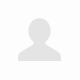
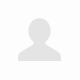

In [13]:
html_source = driver.page_source
html_source

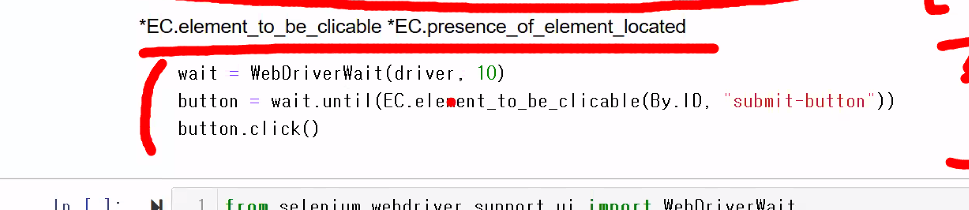

# 웹페이지가 모두 로딩 될 때까지 기다리기
* from selenium.webdrive.support.ui import WebDriverWait
* from selenium.webdrive.support import expected_conditions as EC

*EC.element_to_be_clicable *EC.presence_of_element_located

In [ ]:
wait = WebDriverWait(driver, 10)
button = wait.until(EC.element_to_be_clicable(By.ID, "submit-button"))
button.click()

In [ ]:
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

# 10초 동안 기다리기
wait = WebDriverWait(driver, 10)
# 클릭할 수 있는 요소가 나올 때까지 기다리기
button = wait.until(EC.element_to_be_clicable(By.ID, "submit-button"))
button.clice()

# 네이버 가격비교 도서에서 파이썬 책 찾아서 5페이지 정보 데이터 프레임으로 만들기

In [16]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

options = Options()
options.add_experimental_option("detach", True)
options.add_argument("start-maximized")
options.add_argument("Chrome/135.0.0.0")
options.add_argument("lang=ko_KR")

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
    )
url = "https://search.shopping.naver.com/book/home"
driver.get(url)
wait = WebDriverWait(driver, 10)
search_text_box = wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "._searchInput_search_text_83jy9._searchInput_placeholder_AG5yA._nlog_click")))
search_text_box.send_keys("파이썬")
search_text_box.send_keys(Keys.ENTER)

In [204]:
# 책 목록 전체 가져오기 find_elements
book_list = driver.find_elements(By.CSS_SELECTOR, ".bookListItem_item_book__RbpgP")

In [205]:
# 페이지 시작부터 끝까지 스크롤하기
import time
for scroll in range(0, 8000, 1000):
    driver.execute_script(f"window.scrollTo({0}, {scroll})")
    time.sleep(2)

In [ ]:
# 책 목록 전체 가져오기 find_elements
book_list = driver.find_elements(By.CSS_SELECTOR, ".bookListItem_item_book__RbpgP")

In [206]:
# 책 제목  bookListItem_title__1mWGq
title = driver.find_element(By.CSS_SELECTOR, ".bookListItem_title__1mWGq").text
#세부링크 bookListItem_item_inner__edK7P
detail_link = driver.find_element(By.CSS_SELECTOR, ".bookListItem_item_inner__edK7P > a").get_attribute("href")
# 저자 .bookListItem_define_item__jqcW8.bookListItem_define_data__fu2A5
author = driver.find_element(By.CSS_SELECTOR, ".bookListItem_define_item__jqcW8 > .bookListItem_define_data__fu2A5").text
# 출판사 .bookListItem_define_item__jqcW8 bookListItem_publish__6XykH.bookListItem_define_data__fu2A5
publisher = driver.find_element(By.CSS_SELECTOR, ".bookListItem_publish__6XykH .bookListItem_define_data__fu2A5").text
# 출간일 .bookListItem_detail_date__6_wYJ
pub_date = driver.find_element(By.CSS_SELECTOR, ".bookListItem_detail_date__6_wYJ").text
# 평점 .bookListItem_grade__e60mi
grade = float(driver.find_element(By.CSS_SELECTOR, ".bookListItem_grade__e60mi").text[2:5])
# 가격 .bookPrice_price__Nv4Ee > em
price = int(driver.find_element(By.CSS_SELECTOR, ".bookPrice_price__Nv4Ee > em").text.replace(",", ""))

print(title, detail_link, author, publisher, pub_date, grade, price)

혼자 만들면서 공부하는 파이썬 (37개 라이브러리와 API로 보고서, 차트, 게임, 맵, AI 챗봇 만들기|저자 직강 유튜브 강의, 오픈 채팅 제공) https://cr3.shopping.naver.com/book/adcr?x=GPDF0ayI8UdbB5j9%2FgNoCv%2F%2F%2Fw%3D%3DsUDxxu3qjDnSBcHks08ysdvbQRyMdMd37cHyL02GTODGJnnL5Sdl1Om0OnvyPouDN9Bgpdf10vr0uwg5L7PsEzeICzaftBDIK1DgG6Jx64XlXgcEt4t%2BEwVhRYNw%2BU43RfQADhMl%2BKQdCrDBpfDaHncv%2BjB2erv%2BZ%2Brrs5VHOiTTt4DqiWzfh638rk6r8T8q2rvW58xB1D49unXpRSRrQDP7IntYW81Xs6qvX%2Bsnxc5xra%2BpI6UJu%2BTwtNWUwqdlIFRAYaEKKuytDRBtmkPmhOIe1UR3JCKLxHLOz%2BY47pOBr6kdrp7BvT8OlwZ7P37Yyw5nDbL8fZ%2FGYoIq%2F%2FjqO5XhhwLJwdx%2B2gXINy%2B92DcAtGXKqDkOxP%2ByHJjFfD%2BLObSaYUAR5OgK45HyKFf50r0eq7xa2bs6%2FahMzsv2lyyJ5SQWnPur7KfcO%2F%2BCm%2Fk3izfNVo1KcSVSazeZg7M%2BAaaiu8UijwP2ZPqUkQaimIv%2BRn3pOVdeEbmmL3GF6bx2lUcd8sgPslR1l2EsXiWQ6aIYJNVikDzdEqfyVj%2FjNoX6WAHQL7y5m2kfL9Hg2%2BV5YiTTX73NsM9LC0gIh66H4xkZ0ZvuBE4%2BhLZWkgE7ov7wqHVEaBjWga3OskBmXSIPw9zwlWtJiKOUk1I7q41%2FzjQ%3D%3D&nvMid=52859338841&catId=50010920 문현일 한빛미디어 2025.02.14. 5.0 23400


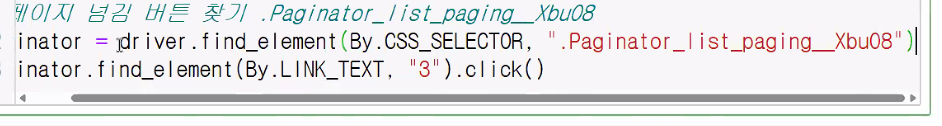

In [19]:
paginator.text

'이전리스트\n12345\n다음리스트'

In [17]:
# 페이지 넘김 버튼 찾기 .Paginator_list_paging__XbuO8
paginator = driver.find_element(By.CSS_SELECTOR, ".Paginator_list_paging__XbuO8")
paginator.find_element(By.LINK_TEXT, "3").click()

# 코드 합쳐서 5페이지 정보 모두 수집하기

In [20]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import time
import pandas as pd

options = Options()
options.add_experimental_option("detach", True)
options.add_argument("start-maximized")
options.add_argument("Chrome/135.0.0.0")
options.add_argument("lang=ko_KR")

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
    )
url = "https://search.shopping.naver.com/book/home"
driver.get(url)
wait = WebDriverWait(driver, 10)
search_text_box = wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "._searchInput_search_text_83jy9._searchInput_placeholder_AG5yA._nlog_click")))
search_text_box.send_keys("파이썬")
search_text_box.send_keys(Keys.ENTER)

for num in range(1, 6):
    # 페이지 시작부터 끝까지 스크롤하기
    for scroll in range(0, 8001, 1000):
        driver.execute_script(f"window.scrollTo({0}, {scroll})")
        time.sleep(2)

    # 책 목록 전체 가져오기 find_elements
    book_list = driver.find_elements(By.CSS_SELECTOR, ".bookListItem_item_book__RbpgP")

    # 반복문을 이용해 전체 40개 책 자료 추출하기
    for book in book_list:
        # 책 제목  bookListItem_title__1mWGq
        title = book.find_element(By.CSS_SELECTOR, ".bookListItem_title__1mWGq").text
        #세부링크 bookListItem_item_inner__edK7P
        detail_link = book.find_element(By.CSS_SELECTOR, ".bookListItem_item_inner__edK7P > a").get_attribute("href")
        # 저자 .bookListItem_define_item__jqcW8.bookListItem_define_data__fu2A5
        author = book.find_element(By.CSS_SELECTOR, ".bookListItem_define_item__jqcW8 > .bookListItem_define_data__fu2A5").text
        # 출판사 .bookListItem_define_item__jqcW8 bookListItem_publish__6XykH.bookListItem_define_data__fu2A5
        publisher = book.find_element(By.CSS_SELECTOR, ".bookListItem_publish__6XykH .bookListItem_define_data__fu2A5").text
        # 출간일 .bookListItem_detail_date__6_wYJ
        pub_date = book.find_element(By.CSS_SELECTOR, ".bookListItem_detail_date__6_wYJ").text
        try:
            # 평점 .bookListItem_grade__e60mi
            grade = float(book.find_element(By.CSS_SELECTOR, ".bookListItem_grade__e60mi").text[2:5])
        except Exception:
            grade = 0.0
        try:    
            # 가격 .bookPrice_price__Nv4Ee > em
            price = int(book.find_element(By.CSS_SELECTOR, ".bookPrice_price__Nv4Ee > em").text.replace(",", ""))
        except Exception:
            price = 0

        temp = (title, detail_link, author, publisher, pub_date, grade, price)
        columns = ("title", "detail_link", "author", "publisher", "pub_date", "grade", "price")
        result = pd.DataFrame([temp], columns=columns)
        # 데이터프레임을 CSV로 저장하되 내용 추가하면서 저장하기
        # mode="a" : append
        result.to_csv("./scraping_results/네이버책_selenium.csv", mode="a", header=False, index=False, encoding="utf-8-sig")
        
    # 페이지 넘김 버튼 찾기 .Paginator_list_paging__XbuO8
    paginator = driver.find_element(By.CSS_SELECTOR, ".Paginator_list_paging__XbuO8")
    paginator.find_element(By.LINK_TEXT, f"{num+1}").click()

# 검색어를 입력받아 Naver 도서에서 검색하고 검색결과를 DB 모듈을 이용해 DB에 저장하기

In [24]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import time
import pandas as pd
from book_dbio import to_book_db


keyword = input("검색할 책을 입력해 주세요. ")

options = Options()
options.add_experimental_option("detach", True)
options.add_argument("start-maximized")
options.add_argument("Chrome/135.0.0.0")
options.add_argument("lang=ko_KR")
# options.add_argument("--headless")  
# options.add_argument("--no-sandbox")
# options.add_argument("--disable-dev-shm-usage")

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
    )


url = "https://search.shopping.naver.com/book/home"
driver.get(url)
wait = WebDriverWait(driver, 10)
search_text_box = wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "._searchInput_search_text_83jy9._searchInput_placeholder_AG5yA._nlog_click")))
search_text_box.send_keys(keyword)
search_text_box.send_keys(Keys.ENTER)

for num in range(1, 6):
    print(f"{num} / {len(range(1,6))} 페이지 작업중", end="\n")
    # 페이지 시작부터 끝까지 스크롤하기
    for scroll in range(0, 8001, 1000):
        driver.execute_script(f"window.scrollTo({0}, {scroll})")
        time.sleep(0.5)

    # 책 목록 전체 가져오기 find_elements
    book_list = driver.find_elements(By.CSS_SELECTOR, ".bookListItem_item_book__RbpgP")

    # 반복문을 이용해 전체 40개 책 자료 추출하기
    for idx, book in enumerate(book_list):
        # 책 제목  bookListItem_title__1mWGq
        title = book.find_element(By.CSS_SELECTOR, ".bookListItem_title__1mWGq").text
        #세부링크 bookListItem_item_inner__edK7P
        detail_link = book.find_element(By.CSS_SELECTOR, ".bookListItem_item_inner__edK7P > a").get_attribute("href")
        try:
            # 저자 .bookListItem_define_item__jqcW8.bookListItem_define_data__fu2A5
            author = book.find_element(By.CSS_SELECTOR, ".bookListItem_define_item__jqcW8 > .bookListItem_define_data__fu2A5").text
        except Exception:
            author = "Unknown"
        try:
            # 출판사 .bookListItem_define_item__jqcW8 bookListItem_publish__6XykH.bookListItem_define_data__fu2A5
            publisher = book.find_element(By.CSS_SELECTOR, ".bookListItem_publish__6XykH .bookListItem_define_data__fu2A5").text
        except Exception:
            publisher = "Unknown"
        try:
            # 출간일 .bookListItem_detail_date__6_wYJ
            pub_date = book.find_element(By.CSS_SELECTOR, ".bookListItem_detail_date__6_wYJ").text
        except Exception:
            pub_date = "Unknown"
        try:
            # 평점 .bookListItem_grade__e60mi
            grade = float(book.find_element(By.CSS_SELECTOR, ".bookListItem_grade__e60mi").text[2:5])
        except Exception:
            grade = 0.0
        try:    
            # 가격 .bookPrice_price__Nv4Ee > em
            price = int(book.find_element(By.CSS_SELECTOR, ".bookPrice_price__Nv4Ee > em").text.replace(",", ""))
        except Exception:
            price = 0

        temp = (title, detail_link, author, publisher, pub_date, grade, price)
        columns = ("title", "detail_link", "author", "publisher", "pub_date", "grade", "price")
        result = pd.DataFrame([temp], columns=columns)
        # 데이터프레임을 CSV로 저장하되 내용 추가하면서 저장하기
        to_book_db(keyword, result)
#         result.to_csv("./scraping_results/네이버책_selenium.csv", mode="a", header=False, index=False, encoding="utf-8-sig")
        print(f"                                                       {idx+1}/{len(book_list)} DB 저장완료", end="\r")
    # 페이지 넘김 버튼 찾기 .Paginator_list_paging__XbuO8
    paginator = driver.find_element(By.CSS_SELECTOR, ".Paginator_list_paging__XbuO8")
    paginator.find_element(By.LINK_TEXT, f"{num+1}").click()

검색할 책을 입력해 주세요. 핀테크
1 / 5 페이지 작업중
2 / 5 페이지 작업중                                          40/40 DB 저장완료
3 / 5 페이지 작업중                                          40/40 DB 저장완료
4 / 5 페이지 작업중                                          40/40 DB 저장완료
5 / 5 페이지 작업중                                          40/40 DB 저장완료


# 한국어 영어로 번역하기

In [ ]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import time
import pandas as pd
from book_dbio import to_book_db


keyword = input("검색할 책을 입력해 주세요. ")
eng_keyword = kor2eng(keyword)

options = Options()
options.add_experimental_option("detach", True)
options.add_argument("start-maximized")
options.add_argument("Chrome/135.0.0.0")
options.add_argument("lang=ko_KR")
# options.add_argument("--headless")  
# options.add_argument("--no-sandbox")
# options.add_argument("--disable-dev-shm-usage")

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
    )


url = "https://search.shopping.naver.com/book/home"
driver.get(url)
wait = WebDriverWait(driver, 10)
search_text_box = wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "._searchInput_search_text_83jy9._searchInput_placeholder_AG5yA._nlog_click")))
search_text_box.send_keys(keyword)
search_text_box.send_keys(Keys.ENTER)

for num in range(1, 6):
    print(f"{num} / {len(range(1,6))} 페이지 작업중", end="\n")
    # 페이지 시작부터 끝까지 스크롤하기
    for scroll in range(0, 8001, 1000):
        driver.execute_script(f"window.scrollTo({0}, {scroll})")
        time.sleep(0.5)

    # 책 목록 전체 가져오기 find_elements
    book_list = driver.find_elements(By.CSS_SELECTOR, ".bookListItem_item_book__RbpgP")

    # 반복문을 이용해 전체 40개 책 자료 추출하기
    for idx, book in enumerate(book_list):
        # 책 제목  bookListItem_title__1mWGq
        title = book.find_element(By.CSS_SELECTOR, ".bookListItem_title__1mWGq").text
        #세부링크 bookListItem_item_inner__edK7P
        detail_link = book.find_element(By.CSS_SELECTOR, ".bookListItem_item_inner__edK7P > a").get_attribute("href")
        try:
            # 저자 .bookListItem_define_item__jqcW8.bookListItem_define_data__fu2A5
            author = book.find_element(By.CSS_SELECTOR, ".bookListItem_define_item__jqcW8 > .bookListItem_define_data__fu2A5").text
        except Exception:
            author = "Unknown"
        try:
            # 출판사 .bookListItem_define_item__jqcW8 bookListItem_publish__6XykH.bookListItem_define_data__fu2A5
            publisher = book.find_element(By.CSS_SELECTOR, ".bookListItem_publish__6XykH .bookListItem_define_data__fu2A5").text
        except Exception:
            publisher = "Unknown"
        try:
            # 출간일 .bookListItem_detail_date__6_wYJ
            pub_date = book.find_element(By.CSS_SELECTOR, ".bookListItem_detail_date__6_wYJ").text
        except Exception:
            pub_date = "Unknown"
        try:
            # 평점 .bookListItem_grade__e60mi
            grade = float(book.find_element(By.CSS_SELECTOR, ".bookListItem_grade__e60mi").text[2:5])
        except Exception:
            grade = 0.0
        try:    
            # 가격 .bookPrice_price__Nv4Ee > em
            price = int(book.find_element(By.CSS_SELECTOR, ".bookPrice_price__Nv4Ee > em").text.replace(",", ""))
        except Exception:
            price = 0

        temp = (title, detail_link, author, publisher, pub_date, grade, price)
        columns = ("title", "detail_link", "author", "publisher", "pub_date", "grade", "price")
        result = pd.DataFrame([temp], columns=columns)
        # 데이터프레임을 CSV로 저장하되 내용 추가하면서 저장하기
        to_book_db(keyword, result)
#         result.to_csv("./scraping_results/네이버책_selenium.csv", mode="a", header=False, index=False, encoding="utf-8-sig")
        print(f"                                                       {idx+1}/{len(book_list)} DB 저장완료", end="\r")
    # 페이지 넘김 버튼 찾기 .Paginator_list_paging__XbuO8
    paginator = driver.find_element(By.CSS_SELECTOR, ".Paginator_list_paging__XbuO8")
    paginator.find_element(By.LINK_TEXT, f"{num+1}").click()